# Results Analysis


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)
pd.set_option('display.precision', 6)

## 1. Custom Functions Benchmark

In [3]:
# Load custom functions results
df_custom = pd.read_csv('results/custom_results.csv')

print(f"Loaded {len(df_custom)} rows")
print(f"Functions: {sorted(df_custom['func_id'].unique())}")
print(f"Methods: {df_custom['method'].unique()}")

Loaded 100 rows
Functions: ['f1', 'f10', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9']
Methods: ['input_adaptive' 'curvature_adaptive']


In [4]:
# Analysis per function
print("=" * 100)
print("CUSTOM FUNCTIONS: Per-Function Analysis")
print("=" * 100)

results_custom = []

for func_id in sorted(df_custom['func_id'].unique()):
    func_data = df_custom[df_custom['func_id'] == func_id]
    
    # Get errors by method
    input_errors = func_data[func_data['method'] == 'input_adaptive']['rel_l2_error'].values
    curv_errors = func_data[func_data['method'] == 'curvature_adaptive']['rel_l2_error'].values
    
    # Calculate statistics
    input_median = np.median(input_errors)
    input_std = np.std(input_errors)
    
    curv_median = np.median(curv_errors)
    curv_std = np.std(curv_errors)
    
    # Percentage improvement (positive means curvature is better)
    improvement = ((input_median - curv_median) / input_median) * 100
    
    results_custom.append({
        'func_id': func_id,
        'input_median': input_median,
        'input_std': input_std,
        'curv_median': curv_median,
        'curv_std': curv_std,
        'improvement_%': improvement
    })
    
    print(f"\n{func_id}:")
    print(f"  Input Adaptive:      Median = {input_median:.6f}, Std = {input_std:.6f}")
    print(f"  Curvature Adaptive:  Median = {curv_median:.6f}, Std = {curv_std:.6f}")
    print(f"  Improvement:         {improvement:+.2f}%")

df_results_custom = pd.DataFrame(results_custom)

# Win/loss summary
curv_wins = (df_results_custom['improvement_%'] > 0).sum()
input_wins = (df_results_custom['improvement_%'] < 0).sum()
ties = (df_results_custom['improvement_%'] == 0).sum()

# Overall improvement statistics
overall_input_median = df_results_custom['input_median'].median()
overall_curv_median = df_results_custom['curv_median'].median()
overall_improvement = ((overall_input_median - overall_curv_median) / overall_input_median) * 100
max_improvement = df_results_custom['improvement_%'].max()
min_improvement = df_results_custom['improvement_%'].min()
avg_improvement = df_results_custom['improvement_%'].mean()

# Statistical significance test (Wilcoxon signed-rank test)
wilcoxon_stat, wilcoxon_p = stats.wilcoxon(
    df_results_custom['input_median'].values,
    df_results_custom['curv_median'].values,
    alternative='greater'
)

print("\n" + "=" * 100)
print(f"WIN/LOSS SUMMARY:")
print(f"  Curvature wins:  {curv_wins}/{len(df_results_custom)} ({curv_wins/len(df_results_custom)*100:.1f}%)")
print(f"  Input wins:      {input_wins}/{len(df_results_custom)} ({input_wins/len(df_results_custom)*100:.1f}%)")
if ties > 0:
    print(f"  Ties:            {ties}/{len(df_results_custom)}")
print(f"\nIMPROVEMENT STATISTICS:")
print(f"  Overall (median of medians): {overall_improvement:+.2f}%")
print(f"  Average improvement:         {avg_improvement:+.2f}%")
print(f"  Maximum improvement:         {max_improvement:+.2f}%")
print(f"  Minimum improvement:         {min_improvement:+.2f}%")
print(f"\nSTATISTICAL SIGNIFICANCE:")
print(f"  Wilcoxon signed-rank test: p-value = {wilcoxon_p:.6f}")
if wilcoxon_p < 0.05:
    print(f"  ✓ Curvature is significantly better (p < 0.05)")
elif wilcoxon_p < 0.10:
    print(f"  ~ Marginal significance (p < 0.10)")
else:
    print(f"  ✗ No significant difference (p >= 0.10)")
print("=" * 100)

CUSTOM FUNCTIONS: Per-Function Analysis

f1:
  Input Adaptive:      Median = 0.034422, Std = 0.004454
  Curvature Adaptive:  Median = 0.029393, Std = 0.004189
  Improvement:         +14.61%

f10:
  Input Adaptive:      Median = 0.080567, Std = 0.055728
  Curvature Adaptive:  Median = 0.085738, Std = 0.037207
  Improvement:         -6.42%

f2:
  Input Adaptive:      Median = 0.002395, Std = 0.000727
  Curvature Adaptive:  Median = 0.001007, Std = 0.001025
  Improvement:         +57.93%

f3:
  Input Adaptive:      Median = 0.013436, Std = 0.002924
  Curvature Adaptive:  Median = 0.009985, Std = 0.000880
  Improvement:         +25.69%

f4:
  Input Adaptive:      Median = 0.002911, Std = 0.002381
  Curvature Adaptive:  Median = 0.001878, Std = 0.001405
  Improvement:         +35.51%

f5:
  Input Adaptive:      Median = 0.010641, Std = 0.005068
  Curvature Adaptive:  Median = 0.006735, Std = 0.012905
  Improvement:         +36.70%

f6:
  Input Adaptive:      Median = 0.002396, Std = 0.00328

In [5]:
# Wall time analysis (excluding first run)
print("\nWall Time Analysis (excluding first run):")
print("=" * 80)

# Exclude seed 42 (first run)
df_custom_no_first = df_custom[df_custom['seed'] != 42]

input_times = df_custom_no_first[df_custom_no_first['method'] == 'input_adaptive']['wall_time'].values
curv_times = df_custom_no_first[df_custom_no_first['method'] == 'curvature_adaptive']['wall_time'].values

input_avg_time = np.mean(input_times)
curv_avg_time = np.mean(curv_times)

print(f"Average wall time - Input Adaptive:      {input_avg_time:.2f} seconds")
print(f"Average wall time - Curvature Adaptive:  {curv_avg_time:.2f} seconds")
print(f"Time overhead:                           {((curv_avg_time - input_avg_time) / input_avg_time * 100):+.2f}%")
print("=" * 80)


Wall Time Analysis (excluding first run):
Average wall time - Input Adaptive:      15.47 seconds
Average wall time - Curvature Adaptive:  17.13 seconds
Time overhead:                           +10.71%


## 2. Feynman Equations Benchmark

In [7]:
# Load Feynman results
df_feynman = pd.read_csv('results/feynman_results.csv')

print(f"Loaded {len(df_feynman)} rows")
print(f"Functions: {sorted(df_feynman['func_name'].unique())}")
print(f"Methods: {df_feynman['method'].unique()}")

Loaded 90 rows
Functions: ['f1', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9']
Methods: ['input_adaptive' 'curvature_adaptive']


In [8]:
# Analysis per function
print("=" * 100)
print("FEYNMAN EQUATIONS: Per-Function Analysis")
print("=" * 100)

results_feynman = []

for func_name in sorted(df_feynman['func_name'].unique()):
    func_data = df_feynman[df_feynman['func_name'] == func_name]
    
    # Get errors by method
    input_errors = func_data[func_data['method'] == 'input_adaptive']['rel_l2_error'].values
    curv_errors = func_data[func_data['method'] == 'curvature_adaptive']['rel_l2_error'].values
    
    # Calculate statistics
    input_median = np.median(input_errors)
    input_std = np.std(input_errors)
    
    curv_median = np.median(curv_errors)
    curv_std = np.std(curv_errors)
    
    # Percentage improvement (positive means curvature is better)
    improvement = ((input_median - curv_median) / input_median) * 100
    
    results_feynman.append({
        'func_name': func_name,
        'input_median': input_median,
        'input_std': input_std,
        'curv_median': curv_median,
        'curv_std': curv_std,
        'improvement_%': improvement
    })
    
    print(f"\n{func_name}:")
    print(f"  Input Adaptive:      Median = {input_median:.6f}, Std = {input_std:.6f}")
    print(f"  Curvature Adaptive:  Median = {curv_median:.6f}, Std = {curv_std:.6f}")
    print(f"  Improvement:         {improvement:+.2f}%")

df_results_feynman = pd.DataFrame(results_feynman)

# Win/loss summary
curv_wins = (df_results_feynman['improvement_%'] > 0).sum()
input_wins = (df_results_feynman['improvement_%'] < 0).sum()
ties = (df_results_feynman['improvement_%'] == 0).sum()

# Overall improvement statistics
overall_input_median = df_results_feynman['input_median'].median()
overall_curv_median = df_results_feynman['curv_median'].median()
overall_improvement = ((overall_input_median - overall_curv_median) / overall_input_median) * 100
max_improvement = df_results_feynman['improvement_%'].max()
min_improvement = df_results_feynman['improvement_%'].min()
avg_improvement = df_results_feynman['improvement_%'].mean()

# Statistical significance test (Wilcoxon signed-rank test)
wilcoxon_stat, wilcoxon_p = stats.wilcoxon(
    df_results_feynman['input_median'].values,
    df_results_feynman['curv_median'].values,
    alternative='greater'
)

print("\n" + "=" * 100)
print(f"WIN/LOSS SUMMARY:")
print(f"  Curvature wins:  {curv_wins}/{len(df_results_feynman)} ({curv_wins/len(df_results_feynman)*100:.1f}%)")
print(f"  Input wins:      {input_wins}/{len(df_results_feynman)} ({input_wins/len(df_results_feynman)*100:.1f}%)")
if ties > 0:
    print(f"  Ties:            {ties}/{len(df_results_feynman)}")
print(f"\nIMPROVEMENT STATISTICS:")
print(f"  Overall (median of medians): {overall_improvement:+.2f}%")
print(f"  Average improvement:         {avg_improvement:+.2f}%")
print(f"  Maximum improvement:         {max_improvement:+.2f}%")
print(f"  Minimum improvement:         {min_improvement:+.2f}%")
print(f"\nSTATISTICAL SIGNIFICANCE:")
print(f"  Wilcoxon signed-rank test: p-value = {wilcoxon_p:.6f}")
if wilcoxon_p < 0.05:
    print(f"  ✓ Curvature is significantly better (p < 0.05)")
elif wilcoxon_p < 0.10:
    print(f"  ~ Marginal significance (p < 0.10)")
else:
    print(f"  ✗ No significant difference (p >= 0.10)")
print("=" * 100)

FEYNMAN EQUATIONS: Per-Function Analysis

f1:
  Input Adaptive:      Median = 0.603549, Std = 0.134929
  Curvature Adaptive:  Median = 0.552376, Std = 0.161202
  Improvement:         +8.48%

f10:
  Input Adaptive:      Median = 0.000511, Std = 0.000288
  Curvature Adaptive:  Median = 0.000438, Std = 0.000145
  Improvement:         +14.36%

f11:
  Input Adaptive:      Median = 0.018282, Std = 0.006812
  Curvature Adaptive:  Median = 0.016648, Std = 0.007078
  Improvement:         +8.94%

f12:
  Input Adaptive:      Median = 0.002177, Std = 0.000272
  Curvature Adaptive:  Median = 0.001945, Std = 0.000390
  Improvement:         +10.66%

f13:
  Input Adaptive:      Median = 0.000449, Std = 0.000205
  Curvature Adaptive:  Median = 0.000371, Std = 0.000671
  Improvement:         +17.51%

f14:
  Input Adaptive:      Median = 0.002075, Std = 0.000491
  Curvature Adaptive:  Median = 0.001767, Std = 0.000610
  Improvement:         +14.81%

f15:
  Input Adaptive:      Median = 0.002343, Std = 0.

In [9]:
# Wall time analysis (excluding first run)
print("\nWall Time Analysis (excluding first run):")
print("=" * 80)

# Exclude seed 44 (first run)
df_feynman_no_first = df_feynman[df_feynman['seed'] != 44]

input_times = df_feynman_no_first[df_feynman_no_first['method'] == 'input_adaptive']['wall_time'].values
curv_times = df_feynman_no_first[df_feynman_no_first['method'] == 'curvature_adaptive']['wall_time'].values

input_avg_time = np.mean(input_times)
curv_avg_time = np.mean(curv_times)

print(f"Average wall time - Input Adaptive:      {input_avg_time:.2f} seconds")
print(f"Average wall time - Curvature Adaptive:  {curv_avg_time:.2f} seconds")
print(f"Time overhead:                           {((curv_avg_time - input_avg_time) / input_avg_time * 100):+.2f}%")
print("=" * 80)


Wall Time Analysis (excluding first run):
Average wall time - Input Adaptive:      15.36 seconds
Average wall time - Curvature Adaptive:  17.62 seconds
Time overhead:                           +14.70%


## 3. Helmholtz PDE Benchmark

In [11]:
# Load Helmholtz results
df_helm = pd.read_csv('results/helmholtz_results.csv')

print(f"Loaded {len(df_helm)} rows")
print(f"Configurations: {sorted(df_helm[['a1', 'a2']].drop_duplicates().values.tolist())}")
print(f"Methods: {df_helm['method'].unique()}")

Loaded 24 rows
Configurations: [[1.0, 1.0], [1.0, 2.0], [2.0, 2.0], [2.0, 4.0]]
Methods: ['input_adaptive' 'curvature_adaptive']


In [12]:
# Analysis per configuration
print("=" * 100)
print("HELMHOLTZ PDE: Per-Configuration Analysis")
print("=" * 100)

results_helm = []

for a1, a2 in sorted(df_helm[['a1', 'a2']].drop_duplicates().values.tolist()):
    config_data = df_helm[(df_helm['a1'] == a1) & (df_helm['a2'] == a2)]
    
    # Get errors by method
    input_errors = config_data[config_data['method'] == 'input_adaptive']['rel_l2_error'].values
    curv_errors = config_data[config_data['method'] == 'curvature_adaptive']['rel_l2_error'].values
    
    # Calculate statistics
    input_median = np.median(input_errors)
    input_std = np.std(input_errors)
    
    curv_median = np.median(curv_errors)
    curv_std = np.std(curv_errors)
    
    # Percentage improvement (positive means curvature is better)
    improvement = ((input_median - curv_median) / input_median) * 100
    
    results_helm.append({
        'a1': a1,
        'a2': a2,
        'input_median': input_median,
        'input_std': input_std,
        'curv_median': curv_median,
        'curv_std': curv_std,
        'improvement_%': improvement
    })
    
    print(f"\nConfiguration (a1={a1}, a2={a2}):")
    print(f"  Input Adaptive:      Median = {input_median:.6f}, Std = {input_std:.6f}")
    print(f"  Curvature Adaptive:  Median = {curv_median:.6f}, Std = {curv_std:.6f}")
    print(f"  Improvement:         {improvement:+.2f}%")

df_results_helm = pd.DataFrame(results_helm)

# Win/loss summary
curv_wins = (df_results_helm['improvement_%'] > 0).sum()
input_wins = (df_results_helm['improvement_%'] < 0).sum()
ties = (df_results_helm['improvement_%'] == 0).sum()

# Overall improvement statistics
overall_input_median = df_results_helm['input_median'].median()
overall_curv_median = df_results_helm['curv_median'].median()
overall_improvement = ((overall_input_median - overall_curv_median) / overall_input_median) * 100
max_improvement = df_results_helm['improvement_%'].max()
min_improvement = df_results_helm['improvement_%'].min()
avg_improvement = df_results_helm['improvement_%'].mean()

# Statistical significance test (Wilcoxon signed-rank test)
wilcoxon_stat, wilcoxon_p = stats.wilcoxon(
    df_results_helm['input_median'].values,
    df_results_helm['curv_median'].values,
    alternative='greater'
)

print("\n" + "=" * 100)
print(f"WIN/LOSS SUMMARY:")
print(f"  Curvature wins:  {curv_wins}/{len(df_results_helm)} ({curv_wins/len(df_results_helm)*100:.1f}%)")
print(f"  Input wins:      {input_wins}/{len(df_results_helm)} ({input_wins/len(df_results_helm)*100:.1f}%)")
if ties > 0:
    print(f"  Ties:            {ties}/{len(df_results_helm)}")
print(f"\nIMPROVEMENT STATISTICS:")
print(f"  Overall (median of medians): {overall_improvement:+.2f}%")
print(f"  Average improvement:         {avg_improvement:+.2f}%")
print(f"  Maximum improvement:         {max_improvement:+.2f}%")
print(f"  Minimum improvement:         {min_improvement:+.2f}%")
print(f"\nSTATISTICAL SIGNIFICANCE:")
print(f"  Wilcoxon signed-rank test: p-value = {wilcoxon_p:.6f}")
if wilcoxon_p < 0.05:
    print(f"  ✓ Curvature is significantly better (p < 0.05)")
elif wilcoxon_p < 0.10:
    print(f"  ~ Marginal significance (p < 0.10)")
else:
    print(f"  ✗ No significant difference (p >= 0.10)")
print("=" * 100)

HELMHOLTZ PDE: Per-Configuration Analysis

Configuration (a1=1.0, a2=1.0):
  Input Adaptive:      Median = 0.018336, Std = 0.006984
  Curvature Adaptive:  Median = 0.012065, Std = 0.006425
  Improvement:         +34.20%

Configuration (a1=1.0, a2=2.0):
  Input Adaptive:      Median = 0.066798, Std = 0.008916
  Curvature Adaptive:  Median = 0.064696, Std = 0.002898
  Improvement:         +3.15%

Configuration (a1=2.0, a2=2.0):
  Input Adaptive:      Median = 0.217129, Std = 0.044781
  Curvature Adaptive:  Median = 0.157090, Std = 0.019007
  Improvement:         +27.65%

Configuration (a1=2.0, a2=4.0):
  Input Adaptive:      Median = 1.082964, Std = 0.289816
  Curvature Adaptive:  Median = 0.778640, Std = 0.094016
  Improvement:         +28.10%

WIN/LOSS SUMMARY:
  Curvature wins:  4/4 (100.0%)
  Input wins:      0/4 (0.0%)

IMPROVEMENT STATISTICS:
  Overall (median of medians): +21.89%
  Average improvement:         +23.27%
  Maximum improvement:         +34.20%
  Minimum improvement:  

In [13]:
# Wall time analysis (excluding first run)
print("\nWall Time Analysis (excluding first run):")
print("=" * 80)

# Exclude seed 3 (first run in the selected seeds)
df_helm_no_first = df_helm[df_helm['seed'] != 3]

input_times = df_helm_no_first[df_helm_no_first['method'] == 'input_adaptive']['wall_time'].values
curv_times = df_helm_no_first[df_helm_no_first['method'] == 'curvature_adaptive']['wall_time'].values

input_avg_time = np.mean(input_times)
curv_avg_time = np.mean(curv_times)

print(f"Average wall time - Input Adaptive:      {input_avg_time:.2f} seconds")
print(f"Average wall time - Curvature Adaptive:  {curv_avg_time:.2f} seconds")
print(f"Time overhead:                           {((curv_avg_time - input_avg_time) / input_avg_time * 100):+.2f}%")
print("=" * 80)


Wall Time Analysis (excluding first run):
Average wall time - Input Adaptive:      61.21 seconds
Average wall time - Curvature Adaptive:  64.30 seconds
Time overhead:                           +5.05%


In [ ]:
def plot_helmholtz_bars(csv_path, save_path=None, 
                        figsize=(8, 5), label_size=14, legend_size=11, tick_size=11,
                        input_color='#d62728',      # Muted Red for Input-based
                        curv_color='#1f77b4'):      # Muted Blue for Curvature-based
    
    # 1. Load and Process Data
    df = pd.read_csv(csv_path)
    
    df['config_str'] = df.apply(lambda row: f"({int(row['a1'])}, {int(row['a2'])})", axis=1)
    config_order = ['(1, 1)', '(1, 2)', '(2, 2)', '(2, 4)']
    
    grouped = df.groupby(['config_str', 'method'])['rel_l2_error'].agg(['median', 'std']).reset_index()
    
    input_stats = grouped[grouped['method'] == 'input_adaptive'].set_index('config_str').reindex(config_order)
    curv_stats = grouped[grouped['method'] == 'curvature_adaptive'].set_index('config_str').reindex(config_order)
    
    input_medians = input_stats['median'].values
    input_stds = input_stats['std'].values
    curv_medians = curv_stats['median'].values
    curv_stds = curv_stats['std'].values
    
    # 2. Setup Plot
    plt.rcParams['font.family'] = 'sans-serif'
    fig, ax = plt.subplots(figsize=figsize)
    
    x = np.arange(len(config_order))
    width = 0.35  

    # 3. Create Bars
    rects1 = ax.bar(x - width/2, input_medians, width, label='Input-Based', 
                    yerr=input_stds, capsize=5, ecolor='black',
                    color=input_color, alpha=0.9, edgecolor='white', linewidth=0.5, zorder=3)
    
    rects2 = ax.bar(x + width/2, curv_medians, width, label='Curvature-Based', 
                    yerr=curv_stds, capsize=5, ecolor='black',
                    color=curv_color, alpha=0.9, edgecolor='white', linewidth=0.5, zorder=3)

    # 4. Styling
    ax.set_ylabel(r'Relative $L^2$ Error (Median)', fontsize=label_size, labelpad=10)
    
    # --- LOG SCALE CHANGE HERE ---
    ax.set_yscale('log') 
    
    ax.set_xticks(x)
    ax.set_xticklabels([r'$(a_1, a_2) = ' + c.strip('()') + r'$' for c in config_order], fontsize=tick_size)
    ax.tick_params(axis='y', labelsize=tick_size)
    
    # Grid and Spines (modified for log scale)
    ax.grid(True, which='major', axis='y', linestyle=':', alpha=0.6, zorder=0)
    ax.grid(True, which='minor', axis='y', linestyle=':', alpha=0.2, zorder=0)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)

    # Legend
    ax.legend(loc='upper left', frameon=True, fontsize=legend_size, framealpha=0.95, edgecolor='#dddddd')

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.tight_layout()
    plt.show()

Figure saved to: results/helmholtz.pdf


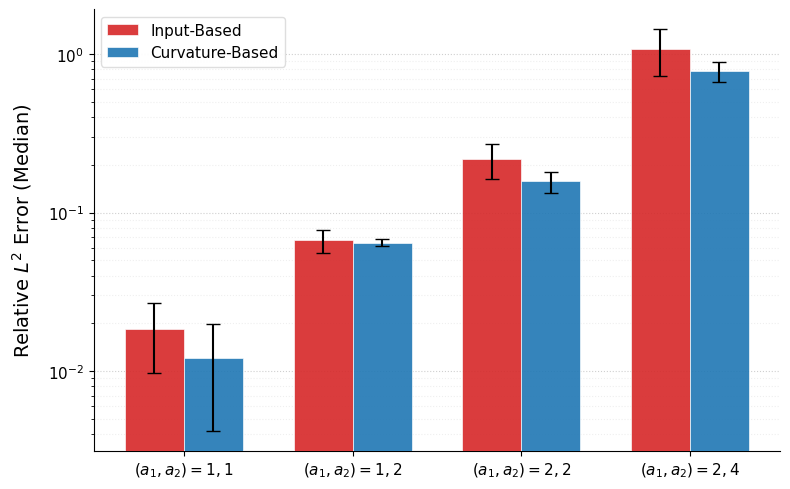

In [4]:
plot_helmholtz_bars('results/helmholtz_results.csv', save_path='results/helmholtz.pdf', figsize=(8, 5), label_size=14, legend_size=11, tick_size=11)

## Summary Tables

In [14]:
print("\n" + "=" * 100)
print("CUSTOM FUNCTIONS - Summary Table")
print("=" * 100)
print(df_results_custom.to_string(index=False))


CUSTOM FUNCTIONS - Summary Table
func_id  input_median  input_std  curv_median  curv_std  improvement_%
     f1      0.034422   0.004454     0.029393  0.004189      14.610380
    f10      0.080567   0.055728     0.085738  0.037207      -6.418514
     f2      0.002395   0.000727     0.001007  0.001025      57.929124
     f3      0.013436   0.002924     0.009985  0.000880      25.686993
     f4      0.002911   0.002381     0.001878  0.001405      35.507244
     f5      0.010641   0.005068     0.006735  0.012905      36.704557
     f6      0.002396   0.003281     0.002120  0.001270      11.488152
     f7      0.000861   0.000862     0.000645  0.000269      25.093101
     f8      0.006729   0.234879     0.005066  0.001848      24.711264
     f9      0.009800   0.003931     0.007076  0.003434      27.800327


In [15]:
print("\n" + "=" * 100)
print("FEYNMAN EQUATIONS - Summary Table")
print("=" * 100)
print(df_results_feynman.to_string(index=False))


FEYNMAN EQUATIONS - Summary Table
func_name  input_median  input_std  curv_median  curv_std  improvement_%
       f1      0.603549   0.134929     0.552376  0.161202       8.478681
      f10      0.000511   0.000288     0.000438  0.000145      14.359771
      f11      0.018282   0.006812     0.016648  0.007078       8.936451
      f12      0.002177   0.000272     0.001945  0.000390      10.660970
      f13      0.000449   0.000205     0.000371  0.000671      17.509553
      f14      0.002075   0.000491     0.001767  0.000610      14.814157
      f15      0.002343   0.000252     0.002111  0.000315       9.887561
       f2      0.000343   0.000096     0.000317  0.000273       7.740861
       f3      0.941333   0.054073     0.746620  0.136305      20.684797
       f4      0.021864   0.000696     0.021688  0.000408       0.808302
       f5      0.999934   0.000017     0.999940  0.000005      -0.000540
       f6      0.999947   0.000016     0.999949  0.000014      -0.000254
       f7      0

In [16]:
print("\n" + "=" * 100)
print("HELMHOLTZ PDE - Summary Table")
print("=" * 100)
print(df_results_helm.to_string(index=False))


HELMHOLTZ PDE - Summary Table
 a1  a2  input_median  input_std  curv_median  curv_std  improvement_%
1.0 1.0      0.018336   0.006984     0.012065  0.006425      34.196179
1.0 2.0      0.066798   0.008916     0.064696  0.002898       3.147429
2.0 2.0      0.217129   0.044781     0.157090  0.019007      27.651267
2.0 4.0      1.082964   0.289816     0.778640  0.094016      28.101009
